<style>
/* Persian text styling */
.jp-RenderedHTMLCommon, .rendered_html, .markdown-body, .jp-MarkdownOutput {
    font-family: Vazir, Tahoma, sans-serif !important;
}
</style>

<div dir="rtl" style="text-align: center; padding: 20px; font-family: Vazir, Tahoma, sans-serif;">
  <h1 style="margin: 0; font-size: 30px;">
    تکلیف ۲: تشخیص لهجه‌ها و گویش‌های ایرانی با شبکه ابداعی Parity-Net
  </h1>
  <p style="margin-top: 12px; font-size: 16px; color: #555;">
    Word Embeddings • PyTorch • Custom Neural Architectures • NLP
  </p>
</div>

<div dir="rtl" style="text-align: right; font-family: Tahoma; line-height: 2;">
  <b>نام و نام خانوادگی:</b> <input type="text" , value="امیرحسین راحتی"><br>
  <b>شماره دانشجویی:</b> <input type="text" , value = "810104303">
</div>

<hr style="border-color: #334155;">

<div dir="rtl" style="text-align: right; line-height: 2; padding: 18px; background-color: #0f172a; color: #f8fafc; border-radius: 14px; font-family: Vazir, Tahoma, sans-serif;">

<b>شیوه‌ی تحویل:</b> ارسال فایل کامل همین نوت‌بوک.<br>
<b>نحوه‌ی نمره‌دهی:</b> بخش اصلی نمره بر اساس درستی پیاده‌سازی‌ها است و بخشی هم به خوانایی و کارایی کد اختصاص دارد. هر بخش از 5 بخش ابتدایی این تمرین 20% نمره را دارد. همچنین پاسخ به بخش 6 اُم نیز 10% نمره اضافی در پی خواهد داشت (110% در مجوع). علاوه بر این‌ها نمره‌اضافی تا 10% بیشتر بسته به کیفیت خروجی، ابداع و تحلیل شما ممکن است تعلق بگیرد.<br>
<b>نسخه‌ی پیشنهادی پایتون:</b> Python 3.12 </br>
<b>مجموعه داده‌ی استفاده شده: </b>فایل داده‌ی همراه با نام <code>sentiment_data.csv</code> در همان پوشه‌ی نوت‌بوک. منبع مجموعه دادگان  <a href="https://github.com/SilkRoadAparsin/Sentiment/tree/main/datasets">این مخزن</a> است. توجه فرمائید که از نسخه‌ای استفاده کنید که در کنار نوت‌بوک برای شما قرار داده شده است. </br>
<b>نکات مهم:</b>
استفاده از هوش مصنوعی نه‌تنها مجاز است، بلکه توصیه می‌شود؛ با این حال، باید بر خروجی آن مسلط باشید و آن را به‌طور کامل درک کرده باشید. همچنین استفاده از اینترنت بلامانع است، اما مشورت با هم‌کلاسی‌ها یا استفاده از پاسخ‌های آن‌ها مجاز نیست و این موضوع بررسی خواهد شد. هدف از طراحی این تمرین، سنجش میزان دانش شما از درس و قدرت تحلیل شماست. در پایان، از برخی دانشجویان ارائه‌ی مجازی گرفته خواهد شد تا اطمینان حاصل شود که پاسخ‌های نوشته شده را کامل درک کرده‌اید و توانایی حل مسائل را دارید.

<hr style="border-color: #334155;">

<b>اجرای محلی (Local):</b><br>
برای اجرای این تکلیف روی سیستم شخصی، فقط این موارد را لازم دارید:
<ul style="margin-top: 8px;">
  <li>Python 3.11 یا بالاتر</li>
  <li>Jupyter Notebook یا JupyterLab</li>
  <li>فایل نوت‌بوک</li>
  <li>فایل داده‌ی همراه با نام <code>sentiment_data.csv</code> در همان پوشه‌ی نوت‌بوک</li>
</ul>

سپس نوت‌بوک را باز کنید و مطمئن شوید فایل <code>sentiment_data.csv</code> کنار آن قرار دارد. ممکن است نیاز باشد برخی کتابخانه‌های پایتون را دانلود کنید. اگر امکان اتصال به مخزن اصلی پایتون را نداشتید، طبق راهنمایی موجود در <a href="https://docs.parspack.com/reference/mirror/pypi-pip/">این لینک</a>، از مخزن داخلی استفاده کنید.
</div>

<hr style="border-color: #334155;">

## <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">اطلاعات کلی</div>

<div dir="rtl" style="text-align: right; line-height: 2; padding: 18px; background-color: #0f172a; color: #f8fafc; border-radius: 14px; font-family: Vazir, Tahoma, sans-serif;">
<b>هدف تمرین:</b> آشنایی با پیاده‌سازی شبکه‌های عصبی پیش‌خور (Feed-Forward) و لایه‌های Embedding در PyTorch برای طبقه‌بندی متن.<br>
<b>قوانین اجرا:</b> تمرین طوری طراحی شده است که نیازی به استفاده از GPU نداشته باشد. فایل دیتاست <code>sentiment_data.csv</code> در کنار نوت‌بوک قرار دارد و نیازی به اینترنت برای دانلود دیتا یا مدل‌های از پیش آموزش‌دیده (Pre-trained) ندارید.<br>
<b>معماری ابداعی:</b> در این تمرین، شما از معماری استانداردی استفاده نمی‌کنید. شبکه شما باید کلمات را بر اساس «زوج یا فرد بودن تعداد حروفشان» تفکیک کند که جزئیات آن در بخش‌های بعدی آمده است.

</div>

### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۱: تحلیل و پیش‌پردازش دادگان (Data Analysis & Preprocessing)</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
در اولین گام، باید با دادگانی که در اختیار دارید آشنا شوید. فایل <code>sentiment_data.csv</code> حاوی جملاتی از زبان‌ها، گویش‌ها و لهجه‌های مختلف ایرانی است. 
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li>فایل دادگان را با استفاده از کتابخانه Pandas بارگذاری کرده و چند سطر نخست آن را برای آشنایی با ساختار ستون‌ها نمایش دهید. توجه فرمائید که هدف پیش‌بینی مادیر ستون <b>accent</b> با استفاده از ستون text یا transliteration یا هر دو است (تصمیم گیری با خودتان!).</li>
    <li><b>تحلیل داده‌ها:</b> تحلیل‌های اکتشافی (EDA) متنوعی را که برای شناخت بهتر مجموعه داده مفید می‌دانید، روی آن انجام دهید. می‌توانید از تکنیک‌های مصورسازی نیز کمک بگیرید. خلاقیت شما در این بخش ارزیابی شده و دارای نمره است.</li>
    <li><b>پیش‌پردازش:</b> اکنون که با داده‌ها آشنا شدید، بررسی کنید که آیا پیش‌پردازش خاصی برای استفاده از آن‌ها نیاز است؟ آیا می‌توان از تمام دادگان به همین شکل استفاده کرد؟ در صورت نیاز، گام‌های پیش‌پردازش (مانند مدیریت مقادیر تهی، حذف یا اصلاح داده‌های نویزی، یکسان‌سازی حروف و پاک‌سازی متن) را پیاده‌سازی و اعمال کنید. (توصیه می‌شود این بخش را هم‌زمان با پیش‌روی در گام‌های بعدی و شناخت نیازهای مدل خود تکمیل کنید.)</li>
    <li>
    تقسیم به دسته‌های آموزش و ارزیابی (و در صورت نیاز به اعتبار سنجی)
    </li>
</ol>
</div>

##### start and load data

In [39]:
import pandas as pd
import numpy as np

df =  pd.read_csv("sentiment_data.csv")
df.describe()

,language,dialect,accent,text,transliteration,sentiment_1,sentiment_2,sentiment_3
count,800,800,800,601,600,701,701,701
unique,7,7,8,601,598,4,3,4
top,Persian,"Persian, Iranian",Tonekaboni,داره بوشُم,golo bolbolo sonbol,negative,negative,negative
freq,200,200,100,1,2,301,316,293


In [40]:
df.head()

,language,dialect,accent,text,transliteration,sentiment_1,sentiment_2,sentiment_3
0,Caspian,Mazandarani,Tonekaboni,داره بوشُم,dare bushom,neutral,neutral,neutral
1,Caspian,Mazandarani,Tonekaboni,خرس اَنه بوخاره، ترکنه (اینه مو ریزنه),"khers ane bokhare, terkene (ine mu rizene)",negative,negative,negative
2,Caspian,Mazandarani,Tonekaboni,مِره وشنایه,mere vashnāye,negative,neutral,negative
3,Caspian,Mazandarani,Tonekaboni,چای نوخارنُم,chāi nokharnom,neutral,negative,neutral
4,Caspian,Mazandarani,Tonekaboni,عالی با؛ ماچ تی جان، تی قربان بوشُم,"āli bā; māch ti jān, ti ghorbān boshum",positive,positive,positive


#### EDA

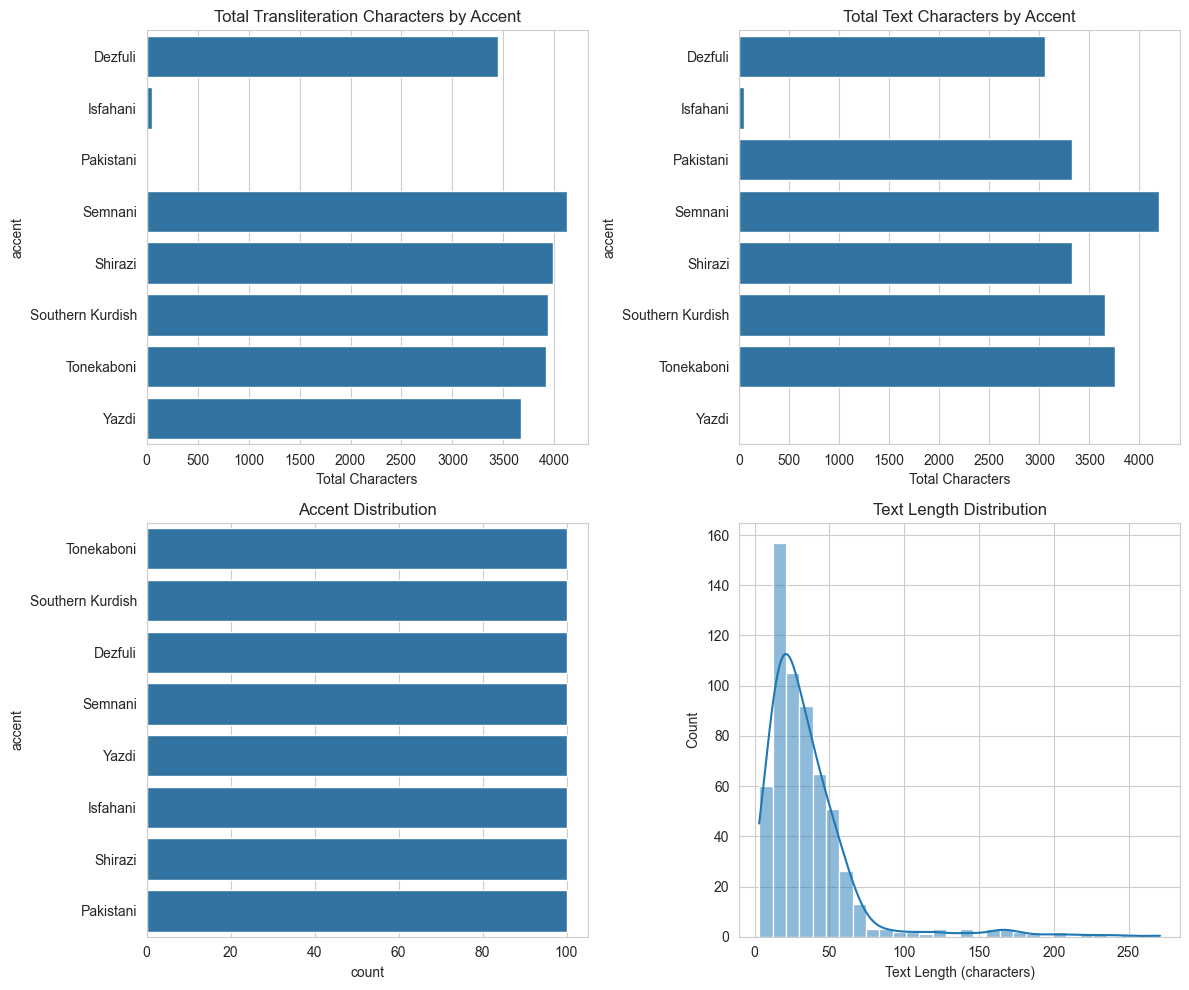

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sentiment_cols = ['sentiment_1', 'sentiment_2', 'sentiment_3']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

translit_length_by_dialect = df.groupby('accent')['transliteration'].apply(lambda x: x.dropna().str.len().sum())
sns.barplot(x=translit_length_by_dialect.values, y=translit_length_by_dialect.index, ax=axes[0, 0])
axes[0, 0].set_title('Total Transliteration Characters by Accent')
axes[0, 0].set_xlabel('Total Characters')

text_length_by_dialect = df.groupby('accent')['text'].apply(lambda x: x.dropna().str.len().sum())
sns.barplot(x=text_length_by_dialect.values, y=text_length_by_dialect.index, ax=axes[0, 1])
axes[0, 1].set_title('Total Text Characters by Accent')
axes[0, 1].set_xlabel('Total Characters')

sns.countplot(data=df, y='accent', ax=axes[1, 0], order=df['accent'].value_counts().index)
axes[1, 0].set_title('Accent Distribution')

text_length = df['text'].dropna().apply(len)
sns.histplot(text_length, bins=30, ax=axes[1, 1], kde=True)
axes[1, 1].set_title('Text Length Distribution')
axes[1, 1].set_xlabel('Text Length (characters)')

plt.tight_layout()
plt.show()

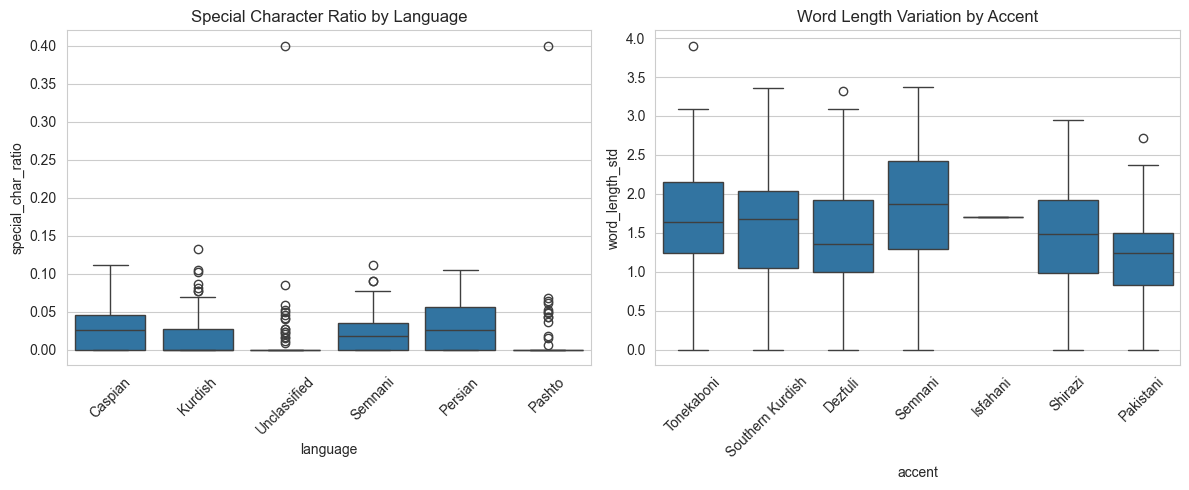

In [42]:
import re

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

special_char_ratio = df['text'].dropna().apply(
    lambda x: len(re.findall(r'[^\w\s\u0600-\u06FF\uFB50-\uFDFF\uFE70-\uFEFF]', str(x))) / max(len(str(x)), 1)
)

temp_df = df.dropna(subset=['text', 'language']).copy()
temp_df['special_char_ratio'] = special_char_ratio.loc[temp_df.index]

sns.boxplot(data=temp_df, x='language', y='special_char_ratio', ax=axes[0])
axes[0].set_title('Special Character Ratio by Language')
axes[0].tick_params(axis='x', rotation=45)

word_length_std = df['text'].dropna().apply(
    lambda x: [len(w) for w in str(x).split()] if str(x).split() else [0]
).apply(lambda lens: np.std(lens) if lens else 0)

temp_df2 = df.dropna(subset=['text', 'accent']).copy()
temp_df2['word_length_std'] = word_length_std.loc[temp_df2.index]

sns.boxplot(data=temp_df2, x='accent', y='word_length_std', ax=axes[1])
axes[1].set_title('Word Length Variation by Accent')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

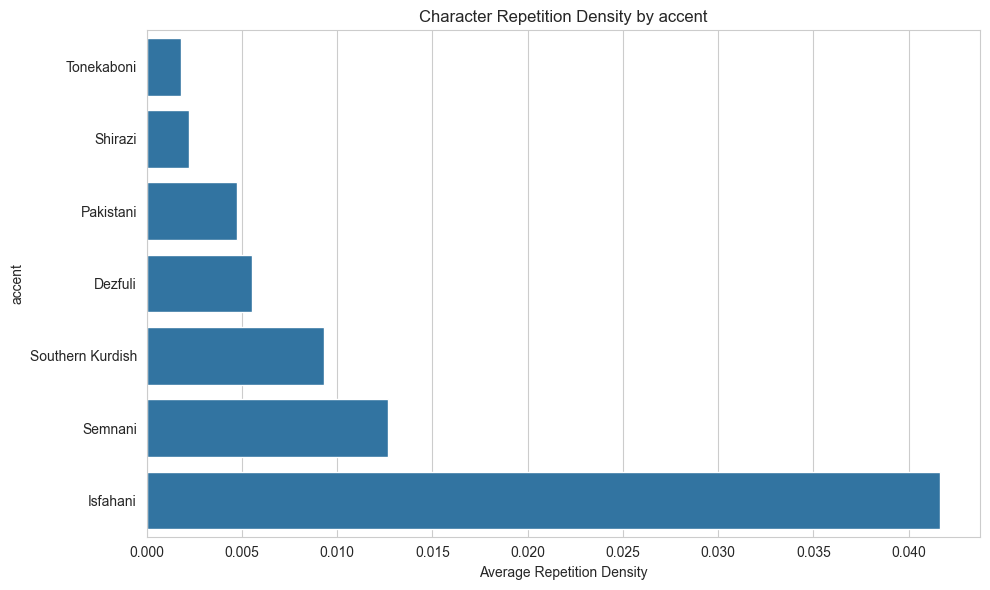

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

def repetition_density(text):
    text = str(text)
    if len(text) < 2:
        return 0
    repeats = sum(1 for i in range(len(text)-1) if text[i] == text[i+1])
    return repeats / len(text)

repetition_values = df['text'].dropna().apply(repetition_density)

temp_df3 = df.dropna(subset=['text', 'accent']).copy()
temp_df3['repetition_density'] = repetition_values.loc[temp_df3.index]

avg_repetition = temp_df3.groupby('accent')['repetition_density'].mean().sort_values()

sns.barplot(x=avg_repetition.values, y=avg_repetition.index, ax=ax)
ax.set_title('Character Repetition Density by accent')
ax.set_xlabel('Average Repetition Density')

plt.tight_layout()
plt.show()

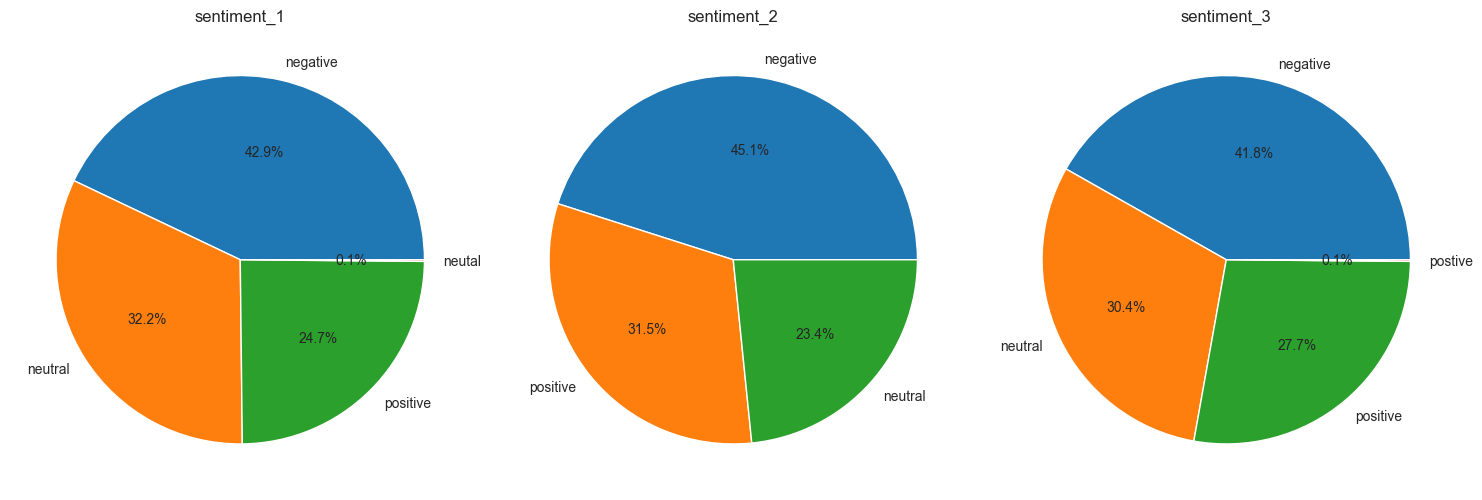

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(sentiment_cols):
    sentiment_counts = df[col].value_counts()
    axes[i].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%')
    axes[i].set_title(f'{col}')

plt.tight_layout()
plt.show()

##### Data preprocessing

In [45]:
def contains_letter(text):
    if pd.isna(text):
        return False
    text = str(text)
    return bool(re.search(r'[آ-یa-zA-Z]', text))


df = df[df["transliteration"].notnull()]
df['sentiment_3'] = df['sentiment_3'].replace('postive', 'positive')
df = df[df['text'].apply(contains_letter) | df['transliteration'].apply(contains_letter)]

df.describe()


,language,dialect,accent,text,transliteration,sentiment_1,sentiment_2,sentiment_3
count,599,599,599,499,599,599,599,599
unique,6,6,7,499,597,4,3,3
top,Persian,"Persian, Iranian",Southern Kurdish,داره بوشُم,golo bolbolo sonbol,negative,negative,negative
freq,101,101,100,1,2,264,286,268


##### Partition to train and test sets

In [46]:
accents = dict()
set_of_accents = list(set(df.accent))
for i in range(len(set_of_accents)):
    accents[set_of_accents[i]] = i


encoded_labels = list()

for idx in range(len(df)):
    encoded_labels.append(accents[df.iloc[idx]["accent"]])

df["encoded_accent"] = encoded_labels


In [47]:
ratio = 0.8

train_df = pd.DataFrame()
test_df = pd.DataFrame()

for acc in accents.keys():
    accent_df = df[df['accent'] == acc].sample(frac = 1, random_state = 123).reset_index(drop = True)
    train_size = int(ratio * len(accent_df))

    train_df = pd.concat([train_df, accent_df[:train_size]], ignore_index=True)
    test_df = pd.concat([test_df, accent_df[train_size:]], ignore_index=True)

X_train = train_df[["text"]]
y_train = train_df["encoded_accent"]

X_test = test_df[["text"]]
y_test = test_df["encoded_accent"]

print(len(X_train) , "---" , len(X_test))

478 --- 121


### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۲: توکنایز کردن متون و ساخت واژه‌نامه (Tokenization & Vocabulary)</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
مدل‌های یادگیری ماشین و شبکه‌های عصبی نمی‌توانند متون خام را به‌طور مستقیم پردازش کنند. بنابراین، باید جملات را به واحدهای کوچکتری به نام «توکن» (Token) بشکنیم و سپس هر توکن را به یک شناسه عددی (Index) منحصربه‌فرد نگاشت کنیم.
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li><b>ساخت واژه‌نامه (Vocabulary):</b> یک دیکشنری (Dictionary) بسازید که هر توکنِ یکتا در دادگان را به یک عدد صحیح اختصاص دهد. 
        <br><i>نکته بسیار مهم:</i> حتماً دو توکن ویژه <code>[PAD]</code> (برای هم‌طول‌سازی جملات، معمولاً با شناسه ۰) و <code>[UNK]</code> (برای کلمات خارج از واژه‌نامه، معمولاً با شناسه ۱) را در ابتدای واژه‌نامه خود تعریف کنید.</li>
    <li><b>توکنایز کردن:</b> تابعی بنویسید که متن پیش‌پردازش‌شده را به لیستی از توکن‌ها تبدیل کند. برای سادگی می‌توانید از جداکننده فاصله (Whitespace) استفاده کنید (مثلاً متد <code>split()</code>). با این حال، استفاده از توکنایزرهای پیشرفته‌تر (مانند توکنایزر <code>Hazm</code>، <code>ParsBERT</code> یا توکنایزرهای مبتنی بر زیرکلمه) می‌تواند دقت مدل شما را، به‌ویژه در برخورد با گویش‌ها و لهجه‌های مختلف این دیتاست، بهبود بخشد و امتیاز تشویقی دارد.</li>
    <li><b>تبدیل متن به شناسه (Encoding):</b> با استفاده از واژه‌نامه، تمام جملات دیتاست را به دنباله‌ای از اعداد تبدیل کنید. کلماتی که در واژه‌نامه وجود ندارند باید به شناسه <code>[UNK]</code> تبدیل شوند.</li>
</ol>
</div>

In [48]:
PAD_TOKEN = "[PAD]"
UNK_TOKEN = "[UNK]"

class Dictionary:
    def __init__(self):
        self.word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
        self.idx2word = {0: PAD_TOKEN, 1: UNK_TOKEN}
        self.last_idx = 1


    def add_token(self, token: str) -> int:
        if token == None:
            return self.word2idx.get(UNK_TOKEN)
        
        idx = self.word2idx.get(token)
        if (idx == None):
            self.last_idx += 1
            self.word2idx[token] = self.last_idx
            self.idx2word[self.last_idx] = token
            
        return self.word2idx.get(token)
    
    def get_idx(self, token: str) -> int:
        if token == None or self.word2idx.get(token) == None:
            return self.word2idx.get(UNK_TOKEN)
        
        return self.word2idx.get(token)
    
    def get_token(self, idx: int) -> str:
        return self.idx2word.get(idx)

    def __len__(self):
        return self.last_idx + 1

In [49]:
def tokenize(text) -> list[str]:
    if not isinstance(text, str):
        return []
    
    return text.split(" ")


def encode_text(tokens : list, dictionary: Dictionary) -> list[int]:
    idxs = list()
    for token in tokens:
        idxs.append(dictionary.get_idx(token))
    return idxs

def check_text_validity(text):
    if pd.isna(text) or str(text).strip() == '' or str(text).lower() == 'nan':
        result = ''
    else:
        result = str(text).strip()
    return result


In [50]:
def tokenize_dataframe(df : pd.DataFrame, dictionary : Dictionary) -> list:
    encoded_values = []
    for idx in df.index:
        text = df.loc[idx, 'text']
        if pd.isna(text) or str(text).strip() == '':
            encoded_values.append([])
            continue
        
        text = str(text).strip()
        tokens = text.split()
        
        for token in tokens:
            if token.strip():
                dictionary.add_token(token)
        
        encoded_values.append(encode_text(tokens, dictionary))
    return encoded_values

train_dictionary = Dictionary()
X_train["encoded_text"] = tokenize_dataframe(X_train, train_dictionary)
X_test["encoded_text"] = tokenize_dataframe(X_test, train_dictionary)

print(f"Total Vocabulary Size: {len(train_dictionary)}")

if X_train is not None and 'encoded_text' in X_train.columns:
    sample_idx = 220
    print("\n--- Sample Encoding ---")
    print("Original Text: ", X_train['text'].iloc[sample_idx])
    print("Tokenized:     ", tokenize(X_train['text'].iloc[sample_idx]))
    print("Encoded IDs:   ", X_train['encoded_text'].iloc[sample_idx])
else:
    print("Encoding step is not completed yet.")


Total Vocabulary Size: 2163

--- Sample Encoding ---
Original Text:  ئبده یه کی بی؟
Tokenized:      ['ئبده', 'یه', 'کی', 'بی؟']
Encoded IDs:    [1139, 1031, 267, 1140]


### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۳: ساخت  Dataset و DataLoader برای پای‌تورچ</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
اکنون هدف ما پیش‌بینی <b>لهجه (Accent)</b> گوینده از روی متن است. شبکه‌های عصبی در PyTorch برای دریافت داده‌ها نیازمند ساختارهایی به نام <b>تنسور (Tensor)</b> و ماتریس‌هایی با ابعاد یکسان هستند. 
<br><br>
از آنجایی که طول جملات ما با هم تفاوت دارد، باید پیش از ارسال آن‌ها به مدل، فرآیند <b>هم‌طول‌سازی (Padding & Truncation)</b> را انجام دهیم. به این صورت که یک طول بیشینه (مثلاً <code>max_len = 30</code>) در نظر می‌گیریم؛ جملات طولانی‌تر را قطع می‌کنیم و به انتهای جملات کوتاه‌تر توکن <code>[PAD]</code> اضافه می‌کنیم تا همگی هم‌اندازه شوند.
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li>کلاس سفارشی <code>AccentDataset</code> را تکمیل کنید. در متد <code>__getitem__</code>، عملیات Truncation و Padding را روی لیست توکن‌ها اعمال کرده و هر دو خروجی (متن و برچسب لهجه) را به <code>torch.tensor</code> با نوع داده‌ی <code>long</code> تبدیل کنید.</li>
    <li>با استفاده از داده‌های آموزش و آزمون (که در مراحل پیشین جدا کرده‌اید)، دو شیء از این کلاس بسازید.</li>
    <li>اشیای <code>train_loader</code> و <code>test_loader</code> را بسازید (مقدار <code>batch_size</code> را ترجیحاً 8 در نظر بگیرید). اطمینان حاصل کنید که دیتالودر مربوط به آموزش، داده‌ها را بُر می‌زند (<code>shuffle=True</code>).</li>
</ol>
</div>

In [51]:
import torch
from torch.utils.data import Dataset, DataLoader

class AccentDataset(Dataset):
    def __init__(self, encoded_texts, accent_labels, max_len=30, pad_token=0):
        self.texts = encoded_texts
        self.labels = accent_labels
        self.max_len = max_len
        self.pad_token = pad_token

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_seq = self.texts[idx]
        label = self.labels[idx]

        if len(text_seq) > self.max_len:
            text_seq = text_seq[:self.max_len]
        else:
            text_seq = text_seq + [self.pad_token] * (self.max_len - len(text_seq))

        text_tensor = torch.tensor(text_seq, dtype=torch.long)
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        return text_tensor, label_tensor

train_dataset = AccentDataset(X_train["encoded_text"].tolist(), y_train.tolist(), 30)
test_dataset = AccentDataset(X_test["encoded_text"].tolist(), y_test.tolist(), 30)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, drop_last=False)

if train_loader is not None:
    sample_batch_texts, sample_batch_labels = next(iter(train_loader))
    print(f"Batch Texts Shape: {sample_batch_texts.shape}")
    print(f"Batch Labels Shape: {sample_batch_labels.shape}")
    print("\nSample Label Tensor:", sample_batch_labels[:5])
else:
    print("DataLoaders are not initialized yet.")

Batch Texts Shape: torch.Size([8, 30])
Batch Labels Shape: torch.Size([8])

Sample Label Tensor: tensor([0, 0, 0, 0, 0])


### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۴: معماری شبکه عصبی ابداعی (Parity-Net)</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
در این مرحله باید شبکه‌ی عصبی خود را طراحی کنید. ما از یک معماری به نام <b>Parity-Net</b> استفاده می‌کنیم. در این شبکه، مدل برای کلماتی که تعداد حروفشان زوج است از یک لایه Embedding، و برای کلماتی که تعداد حروفشان فرد است از یک لایه Embedding دیگر استفاده می‌کند.
<br><br>
<b>قوانین ساخت این معماری (بسیار ساده):</b>
<ol>
    <li><b>تعریف لایه‌ها:</b> در متد <code>__init__</code>، دو لایه Embedding مجزا بسازید:
        <ul>
            <li><code>emb_even</code>: با سایز ورودی برابر با کل واژه‌نامه و بُعد خروجی <b>64</b>.</li>
            <li><code>emb_odd</code>: با سایز ورودی برابر با کل واژه‌نامه و بُعد خروجی <b>64</b>.</li>
        </ul>
    </li>
    <li><b>جدا کردن ایندکس‌ها:</b> شما باید در متد سازنده، لیست ایندکس‌هایی که مربوط به کلمات زوج هستند و لیست ایندکس‌هایی که مربوط به کلمات فرد هستند را پیدا کنید (با یک حلقه <code>for</code> ساده روی <code>word2idx</code>).</li>
    <li><b>فریز کردن متقاطع (Cross-Freezing):</b> برای اینکه لایه زوج فقط کلمات زوج را یاد بگیرد، باید وزن‌های (Weights) مربوط به کلمات فرد را در <code>emb_even</code> <b>صفر و فریز</b> کنید. بالعکس، در <code>emb_odd</code>، وزن‌های مربوط به کلمات زوج را صفر و فریز کنید. (راهنمایی: می‌توانید مستقیماً به <code>emb.weight.data</code> دسترسی پیدا کنید).</li>
    <li><b>جریان داده (Forward Pass):</b> 
        <ul>
            <li>ورودی <code>input_ids</code> را به هر دو امبدینگ بدهید. (چون وزن‌های نامربوط صفر شده‌اند، خروجی <code>emb_even</code> برای کلمات فرد تماماً صفر خواهد بود).</li>
            <li>روی بُعد توکن‌ها (طول جمله) میانگین (mean) بگیرید.</li>
            <li>دو بردار به دست آمده را با هم جمع (Sum) کنید.</li>
            <li>بردار نهایی را از یک لایه خطی (Linear) عبور دهید تا خروجی کلاس‌ها تولید شود.</li>
        </ul>
    </li>
</ol>
</div>

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# Your answer BEGINS HERE
# ==========================================

class ParityNet(nn.Module):
    def __init__(self, vocab_size, word2idx : dict, num_classes):
        super(ParityNet, self).__init__()
        
        # ۱. تعریف امبدینگ‌ها
        self.emb_even = nn.Embedding(vocab_size, 64, padding_idx=0)
        self.emb_odd = nn.Embedding(vocab_size, 64, padding_idx=0)
        
        # ۲. پیدا کردن ایندکس‌های زوج و فرد
        even_indices = []
        odd_indices = []
        
        # حلقه روی word2idx برای پر کردن لیست‌های بالا
        for token, idx in word2idx.items():
            if len(token) % 2 == 0:
                even_indices.append(idx)
            else:
                odd_indices.append(idx)
        
        # ۳. فریز کردن متقاطع (صفر کردن وزن‌های نامربوط در هر لایه)
        # دقت: برای جلوگیری از آپدیت شدن این وزن‌های صفر، requires_grad آن‌ها را false نمی‌کنیم، 
        # بلکه کلاً دیتای آن‌ها را صفر نگه می‌داریم (این یک روش ساده برای درک مفهوم است).
        
        with torch.no_grad():
            if len(odd_indices) > 0:
                self.emb_even.weight.data[odd_indices] = 0.0
            if len(even_indices) > 0:
                self.emb_odd.weight.data[even_indices] = 0.0
                
        # ۴. لایه خروجی
        self.fc = nn.Linear(64, num_classes)

    def forward(self, input_ids):
        # input_ids shape: (Batch, 30)
        
        # 1. عبور از امبدینگ‌ها
        e_emb = self.emb_even(input_ids)  # shape: (Batch, 30, 64)
        o_emb = self.emb_odd(input_ids)   # shape: (Batch, 30, 64)
        
        # 2. میانگین‌گیری روی طول جمله (بُعد کلمات)
        e_emb = e_emb.mean(dim=1)
        o_emb = o_emb.mean(dim=1)
        
        # 3. جمع دو بردار
        combined = e_emb + o_emb
        
        # 4. عبور از لایه خطی و خروجی
        output = self.fc(combined)
        
        return output

# ==========================================
# Your answer ENDS HERE
# ==========================================

# کدهای ارزیابی معماری
try:
    dummy_word2idx = {"[PAD]": 0, "salam": 1, "khoobi": 2}
    dummy_model = ParityNet(vocab_size=3, word2idx=dummy_word2idx, num_classes=5)
    dummy_inputs = torch.randint(0, 3, (16, 30))
    dummy_output = dummy_model(dummy_inputs)
    print("\nModel Output Shape:", dummy_output.shape) 
    print("If you see (16, 5) without errors, your architecture is correct!")
except Exception as e:
    print("\nError in model architecture:", e)


Model Output Shape: torch.Size([16, 5])
If you see (16, 5) without errors, your architecture is correct!


### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۵: حلقه آموزش و ارزیابی (Training Loop & Evaluation)</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
اکنون که مدل ابداعی خود (Parity-Net) را طراحی کرده‌اید، نوبت به آموزش آن می‌رسد. در این مرحله باید مدل را با استفاده از داده‌های آموزش تغذیه کرده و خطای آن را کاهش دهید.
<br><br>
<b>یک پیام مهم در مورد نمره‌دهی:</b>
هدف اصلی این تمرین، پیاده‌سازی صحیح معماری، جریان داده‌ها و درک مفاهیم است. از آنجایی که فرض بر این است که شما از <b>CPU</b> برای پردازش استفاده می‌کنید، انتظار نداریم که به بالاترین دقت‌های ممکن برسید. <b>در صورت پیاده‌سازی درست مراحل قبلی و اجرای موفقیت‌آمیز مدل حتی برای حداقل ۵ اِپاک (Epoch)، نمره کامل این بخش را دریافت خواهید کرد.</b> البته، رسیدن به دقت‌های بالاتر (با تنظیم بهتر هایپرپارامترها یا با استفاده درست‌تر از دادگانی که در اختیار داشتید) دارای امتیاز تشویقی است.
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li>مدل <code>ParityNet</code> را مقداردهی اولیه کنید (کلاس آن را فراخوانی کنید).</li>
    <li>تابع خطا (Loss Function) را از نوع <code>CrossEntropyLoss</code> انتخاب کنید و بهینه‌ساز (Optimizer) را روی <code>Adam</code> یا <code>SGD</code> تنظیم کنید.</li>
    <li><b>حلقه آموزش (Training Loop):</b> یک حلقه برای تعداد مشخصی Epoch بنویسید (مثلاً ۵ تا ۱۰ اِپاک). در هر اِپاک:
        <ul>
            <li>داده‌ها را از <code>train_loader</code> بخوانید.</li>
            <li>گرادیان‌ها را صفر کنید (<code>optimizer.zero_grad()</code>).</li>
            <li>داده‌ها را به مدل بدهید (Forward Pass) و مقدار خطا (Loss) را محاسبه کنید.</li>
            <li>خطا را در شبکه به عقب پخش کنید (<code>loss.backward()</code>) و وزن‌ها را آپدیت کنید (<code>optimizer.step()</code>).</li>
        </ul>
    </li>
    <li><b>ارزیابی مدل (Evaluation):</b> پس از پایان آموزش، مدل را در حالت ارزیابی (<code>model.eval()</code>) قرار داده و با استفاده از معیارهای ارزیابی مناسب عملکرد مدل را بسنجید.</li>
</ol>
</div>

In [53]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

model = ParityNet(vocab_size= len(train_dictionary), word2idx= train_dictionary.word2idx, num_classes= len(accents))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    
    total_loss = 0
    for batch_texts, batch_labels in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_texts)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

model.eval()

predictions = []
gold_labels = []
total_samples = 0

with torch.no_grad():
    for batch_texts, batch_labels in test_loader:
        outputs = model(batch_texts)
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        gold_labels.extend(batch_labels.cpu().numpy())
        total_samples += len(batch_labels)

accuracy = accuracy_score(gold_labels, predictions)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(gold_labels, predictions, zero_division=0))
print(accents)

Epoch 1/50 | Loss: 1.9618
Epoch 2/50 | Loss: 1.9296
Epoch 3/50 | Loss: 1.9016
Epoch 4/50 | Loss: 1.8706
Epoch 5/50 | Loss: 1.8349
Epoch 6/50 | Loss: 1.7929
Epoch 7/50 | Loss: 1.7438
Epoch 8/50 | Loss: 1.6869
Epoch 9/50 | Loss: 1.6228
Epoch 10/50 | Loss: 1.5524
Epoch 11/50 | Loss: 1.4772
Epoch 12/50 | Loss: 1.3990
Epoch 13/50 | Loss: 1.3197
Epoch 14/50 | Loss: 1.2409
Epoch 15/50 | Loss: 1.1643
Epoch 16/50 | Loss: 1.0912
Epoch 17/50 | Loss: 1.0224
Epoch 18/50 | Loss: 0.9586
Epoch 19/50 | Loss: 0.8998
Epoch 20/50 | Loss: 0.8461
Epoch 21/50 | Loss: 0.7972
Epoch 22/50 | Loss: 0.7527
Epoch 23/50 | Loss: 0.7123
Epoch 24/50 | Loss: 0.6755
Epoch 25/50 | Loss: 0.6420
Epoch 26/50 | Loss: 0.6115
Epoch 27/50 | Loss: 0.5835
Epoch 28/50 | Loss: 0.5579
Epoch 29/50 | Loss: 0.5342
Epoch 30/50 | Loss: 0.5125
Epoch 31/50 | Loss: 0.4923
Epoch 32/50 | Loss: 0.4736
Epoch 33/50 | Loss: 0.4563
Epoch 34/50 | Loss: 0.4400
Epoch 35/50 | Loss: 0.4249
Epoch 36/50 | Loss: 0.4107
Epoch 37/50 | Loss: 0.3974
Epoch 38/5

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
<b>ارزیابی و تحلیل شما بابت نتایج به دست آمده چیست؟ (در خط بعدی همین markdown بنویسید.)</b>
<br><br>
پاسخ شما:
<br><br>
مدل با دقت 65 درصدی روی داده‌های تست عملکرد قابل قبولی داشته است. کاهش loss از 1.93 به 0.17 نشان می‌دهد که شبکه به خوبی آموزش دیده است. با این حال، عملکرد مدل برای کلاس‌های Dezfuli و Tonekaboni (با recall 0.40 و 0.35) ضعیف است که نشان می‌دهد معماری ParityNet مبتنی بر طول کلمات برای تشخیص این لهجه‌ها ویژگی‌های کافی استخراج نمی‌کند.
</div>

### <div dir="rtl" style="text-align: right; font-family: Vazir, Tahoma, sans-serif;">بخش ۶: تحلیل خطا (Error Analysis) - بخش امتیازی و تحلیلی</div>

<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
در دنیای واقعی پردازش زبان طبیعی (NLP)، رسیدن به یک دقت بالا پایان کار نیست. مهندسان ماشین‌لرنینگ همیشه بررسی می‌کنند که مدلشان در چه مواقعی <b>اشتباه</b> می‌کند تا بتوانند نقاط ضعف آن را پوشش دهند (مثلاً شاید مدل با یک گویش خاص مشکل داشته باشد یا توکنایزر به درستی کار نکرده باشد).
<br><br>
<b>وظایف شما در این بخش:</b>
<ol>
    <li><b>استخراج خطاها (کدنویسی):</b> کدی بنویسید که ۳ جمله‌ای را که مدل شما روی آن‌ها <b>بیشترین میزان اطمینان در اشتباه کردن</b> را داشته است پیدا کند. (یعنی مدل با احتمال بالا مثلاً ۹۰٪ گفته این لهجه گیلکی است، اما در واقعیت لری بوده است).</li>
    <li>چاپ نتایج شامل: متن اصلی جمله، لهجه واقعی (True Label) و لهجه پیش‌بینی‌شده توسط مدل (Predicted Label) همراه با احتمال پیش‌بینی (Confidence).</li>
    <li><b>تحلیل زبان‌شناختی (متنی):</b> در یک سلول Markdown زیرِ کدهایتان، به طور خلاصه تحلیل کنید که <b>چرا</b> مدل در این جملات اشتباه کرده است؟ 
        <ul>
            <li>آیا کلمات مشترکی بین این دو لهجه وجود دارد؟</li>
            <li>آیا طول جمله (خیلی کوتاه یا خیلی بلند بودن) باعث خطا در میانگین‌گیری و جمع‌گیری (Sum) بردارهای زوج و فرد شده است؟</li>
            <li>آیا نویزی در دیتاست (برچسب‌گذاری اشتباه توسط انسان) وجود دارد؟</li>
        </ul>
    </li>
</ol>
</div>

In [63]:
import torch.nn.functional as F

print("--- Top 3 Model Errors ---")

errors = []

model.eval()

with torch.no_grad():
    for batch_idx, (batch_texts, batch_labels) in enumerate(test_loader):
        logits = model(batch_texts)
        probs = F.softmax(logits, dim=1)
        max_probs, predicted_labels = torch.max(probs, dim=1)
        
        for i in range(len(batch_labels)):
            if predicted_labels[i] != batch_labels[i]:
                global_idx = batch_idx * BATCH_SIZE + i
                
                true_label_name = [k for k, v in accents.items() if v == batch_labels[i].item()][0]
                pred_label_name = [k for k, v in accents.items() if v == predicted_labels[i].item()][0]
                
                errors.append({
                    'confidence': max_probs[i].item(),
                    'true_label': true_label_name,
                    'pred_label': pred_label_name,
                    'text': X_test.iloc[global_idx]['text']
                })

errors.sort(key=lambda x: x['confidence'], reverse=True)

for i in range(min(3, len(errors))):
    err = errors[i]
    print(f"\n--- Error {i+1} ---")
    print(f"Text: {err['text']}")
    print(f"True Label: {err['true_label']}")
    print(f"Predicted Label: {err['pred_label']}")
    print(f"Confidence: {err['confidence']:.2%}")


--- Top 3 Model Errors ---

--- Error 1 ---
Text: جنگلی که شتر دیدَ
True Label: Dezfuli
Predicted Label: Shirazi
Confidence: 82.78%

--- Error 2 ---
Text: خیلی عالی و به‌موقع. ممنون از شُمو.
True Label: Shirazi
Predicted Label: Tonekaboni
Confidence: 72.98%

--- Error 3 ---
Text: برعکسی ننه‌ش که عاقل بود خودش انگار درا دیوونه‌س
True Label: Isfahani
Predicted Label: Shirazi
Confidence: 70.86%


<div dir="rtl" style="text-align: right; line-height: 2; font-family: Vazir, Tahoma, sans-serif;">
<b>تحلیل خطاهای مدل:</b>
<br><br>
مدل در این سه نمونه به دلیل کوتاه بودن جملات نتوانسته تشخیص درستی داشته باشد، زیرا میانگین‌گیری روی تعداد کم کلمات، بردار نهایی را تحت تأثیر وزن یک یا دو توکن خاص قرار داده است. همچنین بسیاری از توکن‌های این جملات بین لهجه اصلی و لهجه پیش‌بینی‌شده مشترک هستند که باعث سردرگمی مدل شده است. برخی توکن‌ها نیز بسامد بسیار پایینی در دیتاست آموزش دارند و مدل به دلیل حجم محدود داده، نتوانسته نمایش معنا‌داری برای آن‌ها یاد بگیرد. افزودن جملات بلندتر و متنوع‌تر به دیتاست آموزش می‌تواند این مشکل را کاهش دهد.
</div>